In [23]:
import cv2
import cv2
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [24]:
from sklearn.cluster import KMeans
import numpy as np
from sklearn.metrics import pairwise_distances_argmin_min

def balanced_k_means(data, k, cluster_size, max_iter=100, num_initializations=10):
    """
    Perform Balanced K-means clustering using scikit-learn.
    
    Args:
        data (ndarray): Data points (n_samples, n_features).
        k (int): Number of clusters.
        cluster_size (int): Desired size of each cluster.
        max_iter (int): Maximum number of iterations for k-means.
        num_initializations (int): Number of initializations to try.
    
    Returns:
        best_labels (ndarray): Cluster labels for each data point.
        best_centroids (ndarray): Final centroids with the lowest inertia.
        best_inertia (float): Minimum inertia achieved.
    """
    n_samples, n_features = data.shape
    assert n_samples == k * cluster_size, "Number of samples must be divisible by cluster size."

    best_inertia = np.inf
    best_labels = None
    best_centroids = None

    for init in range(num_initializations):
        # Use scikit-learn's KMeans to cluster data
        kmeans = KMeans(
            n_clusters=k,
            init='k-means++',
            max_iter=max_iter,
            n_init=1,
            random_state=init
        )
        kmeans.fit(data)

        # Get initial cluster labels and centroids
        initial_labels = kmeans.labels_
        centroids = kmeans.cluster_centers_

        # Enforce balance by reassigning points to clusters
        distances, _ = pairwise_distances_argmin_min(data, centroids)
        sorted_indices = np.argsort(distances)
        clusters = [[] for _ in range(k)]

        for idx in sorted_indices:
            # Assign the point to the least populated cluster
            for cluster_id in range(k):
                if len(clusters[cluster_id]) < cluster_size:
                    clusters[cluster_id].append(idx)
                    break

        # Update labels to reflect balanced assignment
        balanced_labels = np.zeros(n_samples, dtype=int)
        for cluster_id, cluster_indices in enumerate(clusters):
            for idx in cluster_indices:
                balanced_labels[idx] = cluster_id

        # Compute inertia for the balanced clustering
        inertia = sum(
            np.sum((data[clusters[cluster_id]] - centroids[cluster_id])**2)
            for cluster_id in range(k)
        )

        # Update best solution if this is the best inertia so far
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = balanced_labels
            best_centroids = centroids

    return best_labels, best_centroids, best_inertia

In [25]:

# Function to draw a smaller, centered 3x3 grid on an image
def draw_centered_grid(image, grid_size=100):
    h, w, _ = image.shape
    center_x, center_y = w // 2, h // 2

    # Calculate the grid boundaries
    half_size = grid_size // 2
    top_left_x, top_left_y = center_x - half_size, center_y - half_size
    bottom_right_x, bottom_right_y = center_x + half_size, center_y + half_size

    # Draw the grid
    cell_size = grid_size // 3
    for i in range(4):
        y = top_left_y + i * cell_size
        x = top_left_x + i * cell_size
        cv2.line(image, (top_left_x, y), (bottom_right_x, y), (255, 255, 255), 2)
        cv2.line(image, (x, top_left_y), (x, bottom_right_y), (255, 255, 255), 2)

    return image, (top_left_x, top_left_y, cell_size)


# Function to detect the dominant color in a square
def detect_dominant_color(square, neighborhood_fraction=0.25, blur_ksize=5):
    h, w, _ = square.shape
    center_x, center_y = w // 2, h // 2

    # Define the neighborhood size
    offset_x = int(w * neighborhood_fraction // 2)
    offset_y = int(h * neighborhood_fraction // 2)

    # Extract the neighborhood region
    neighborhood = square[center_y - offset_x:center_y + offset_x, center_x - offset_y:center_x + offset_y]

    # Apply Gaussian blur to the neighborhood
    blurred = cv2.GaussianBlur(neighborhood, (blur_ksize, blur_ksize), 0)

    # Calculate the average color in the blurred neighborhood
    avg_color = blurred.mean(axis=0).mean(axis=0)
    return tuple(map(int, avg_color))  # Convert to (B, G, R)


# Initialize webcam
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

captured_faces = []  # List to store captured face images
color_data = []  # List to store color data for each face
capture_limit = 6  # Number of faces to capture

while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame.")
        break

    # Draw the smaller, centered 3x3 grid on the frame
    grid_frame, grid_info = draw_centered_grid(frame.copy(), grid_size=200)

    # Display the live webcam feed with the smaller grid overlay
    cv2.imshow('Align Your Cube and Press Space', grid_frame)

    key = cv2.waitKey(1)

    if key == ord('q') or key == 27:  # Quit on 'q' or 'Esc'
        break
    elif key == ord(' '):  # Capture on spacebar
        if len(captured_faces) < capture_limit:
            captured_faces.append(frame.copy())
            print(f"Captured face {len(captured_faces)}")

            # Analyze grid colors
            top_left_x, top_left_y, cell_size = grid_info
            colors = []
            for i in range(3):
                for j in range(3):
                    x1 = top_left_x + j * cell_size
                    y1 = top_left_y + i * cell_size
                    x2 = x1 + cell_size
                    y2 = y1 + cell_size
                    square = frame[y1:y2, x1:x2]
                    dominant_color = detect_dominant_color(square)
                    colors.append(dominant_color)
            color_data.append(colors)
        else:
            print("All 6 faces have already been captured!")

    # Check if all faces are captured
    if len(captured_faces) == capture_limit:
        break

cap.release()
cv2.destroyAllWindows()

print(color_data)
# Display the final color palette
if len(color_data) == capture_limit:
    # Create a blank canvas for the color palette
    palette_height = 300
    palette_width = 600
    palette = np.zeros((palette_height, palette_width, 3), dtype=np.uint8)

    face_width = palette_width // 6  # Width of each face in the palette
    cell_size = face_width // 3     # Size of each cell within a face

    for face_idx, face_colors in enumerate(color_data):
        for i in range(3):
            for j in range(3):
                color = face_colors[i * 3 + j]
                top_left_x = face_idx * face_width + j * cell_size
                top_left_y = i * cell_size
                bottom_right_x = top_left_x + cell_size
                bottom_right_y = top_left_y + cell_size
                cv2.rectangle(
                    palette,
                    (top_left_x, top_left_y),
                    (bottom_right_x, bottom_right_y),
                    color,  # Convert BGR to RGB for OpenCV
                    -1  # Filled rectangle
                )

    # Show the color palette
    cv2.imshow('Cube Color Palette', palette)

    # Wait for user input to close the window
    print("Press any key in the 'Cube Color Palette' window to close.")
    while True:
        if cv2.waitKey(1) & 0xFF in {ord('q'), 27}:  # Quit on 'q' or 'Esc'
            break

    # Destroy the palette window
    cv2.destroyAllWindows()

Captured face 1
Captured face 2
Captured face 3
Captured face 4
Captured face 5
Captured face 6
[[(207, 183, 58), (35, 95, 248), (37, 92, 249), (52, 211, 92), (188, 207, 208), (33, 91, 249), (20, 221, 205), (191, 205, 206), (195, 174, 52)], [(201, 178, 61), (187, 200, 196), (36, 93, 244), (30, 90, 254), (30, 90, 248), (49, 200, 84), (192, 206, 206), (199, 172, 45), (185, 202, 199)], [(56, 206, 94), (53, 203, 91), (41, 96, 246), (11, 215, 191), (52, 207, 88), (16, 213, 208), (51, 29, 222), (20, 218, 196), (55, 26, 226)], [(60, 215, 103), (58, 23, 241), (196, 211, 212), (209, 185, 54), (61, 35, 235), (207, 181, 51), (60, 36, 233), (57, 23, 237), (54, 218, 96)], [(191, 209, 213), (39, 104, 249), (17, 214, 204), (198, 216, 210), (207, 185, 55), (55, 29, 222), (58, 217, 98), (198, 216, 221), (14, 222, 206)], [(26, 221, 215), (54, 31, 223), (52, 27, 222), (203, 179, 55), (12, 220, 207), (10, 212, 200), (199, 176, 54), (49, 205, 86), (31, 93, 242)]]
Press any key in the 'Cube Color Palette' w

In [26]:
# Example data in BGR format
lab_data_bgr = np.array(color_data)

# Flatten the data to a 2D array of shape (n_samples, 3)
lab_data_bgr_flat = lab_data_bgr.reshape(-1, 3).astype(np.uint8)

# Convert from BGR to LAB using OpenCV
# Reshape the data into a proper image format for color conversion
lab_data_bgr_image = lab_data_bgr_flat.reshape(lab_data_bgr.shape[0], lab_data_bgr.shape[1], 3)  # reshape to (height, width, 3)

lab_data_lab = cv2.cvtColor(lab_data_bgr_image, cv2.COLOR_BGR2LAB)

# Now `lab_data_lab` contains the data in LAB color space
print(lab_data_lab)

k = 6
cluster_size = 9


# Flatten `lab_data` into a 2D array
lab_data_flat = np.array(lab_data_lab).reshape(-1, 3)

# Perform Balanced K-means
labels, centroids, inertia = balanced_k_means(lab_data_flat, k, cluster_size, 100, 1)

# Print results
print("Cluster Labels:", labels)
print("Centroids in LAB:", centroids)
print("Inertia:", inertia)

[[[176 102 106]
  [153 184 189]
  [153 186 188]
  [193  67 192]
  [211 125 138]
  [152 186 189]
  [215 102 209]
  [210 126 135]
  [168 102 108]]

 [[172 103 107]
  [204 124 134]
  [151 184 187]
  [154 188 191]
  [151 186 190]
  [183  69 189]
  [210 125 135]
  [166 103 105]
  [206 124 136]]

 [[189  70 189]
  [186  70 189]
  [153 183 186]
  [208  99 208]
  [189  68 191]
  [210 107 208]
  [122 198 168]
  [211 100 208]
  [124 200 166]]

 [[197  69 191]
  [131 204 169]
  [215 126 136]
  [177 101 106]
  [130 200 166]
  [174 102 105]
  [129 199 166]
  [129 203 168]
  [199  66 194]]

 [[214 126 137]
  [158 180 189]
  [210 105 208]
  [218 123 136]
  [177 101 107]
  [122 198 166]
  [198  67 192]
  [220 127 137]
  [216 102 210]]

 [[217 106 209]
  [123 198 167]
  [122 198 167]
  [172 102 106]
  [215 103 210]
  [208 104 208]
  [170 102 107]
  [187  68 191]
  [150 183 189]]]
Cluster Labels: [3 5 5 2 0 5 4 0 3 3 0 5 5 5 2 0 3 0 2 2 5 4 2 4 1 4 1 2 1 0 3 1 3 1 1 2 0
 5 4 0 3 1 2 0 4 4 1 1 3 4 4 3 2 

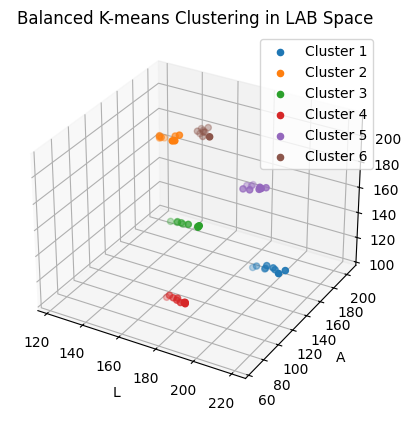

In [27]:
# Convert centroids back to BGR for visualization
bgr_centroids = np.array([cv2.cvtColor(np.uint8([[lab]]), cv2.COLOR_Lab2BGR)[0][0] for lab in centroids])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for i in range(k):
    cluster_points = lab_data_flat[labels == i]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1], cluster_points[:, 2], label=f"Cluster {i+1}")

ax.set_xlabel('L')
ax.set_ylabel('A')
ax.set_zlabel('B')
ax.legend()
plt.title("Balanced K-means Clustering in LAB Space")
plt.show()

In [28]:
# Flatten lab_data for easier processing with labels
lab_data_flat = np.array(lab_data_lab).reshape(-1, 3)

# Print the indices of items in each cluster
print("Clusters and their indices in the original data list:")

for i in range(k):
    # Find the indices of items belonging to the current cluster
    cluster_indices = np.where(labels == i)[0]  # Indices in the flattened array
    print(f"\nCluster {i+1} (Total points: {len(cluster_indices)}):")
    print(cluster_indices)


Clusters and their indices in the original data list:

Cluster 1 (Total points: 9):
[ 4  7 10 15 17 29 36 39 43]

Cluster 2 (Total points: 9):
[24 26 28 31 33 34 41 46 47]

Cluster 3 (Total points: 9):
[ 3 14 18 19 22 27 35 42 52]

Cluster 4 (Total points: 9):
[ 0  8  9 16 30 32 40 48 51]

Cluster 5 (Total points: 9):
[ 6 21 23 25 38 44 45 49 50]

Cluster 6 (Total points: 9):
[ 1  2  5 11 12 13 20 37 53]


In [29]:
# Define cluster-to-color mapping
centre_indices = [4, 22, 13, 31, 40, 49]
picture_order = [0, 2, 1, 3, 4, 5]
color_order = ['W', 'G', 'O', 'R', 'B', 'Y']
cluster_to_color = {}
for i in range(6):
    cluster_to_color[labels[centre_indices[i]]] = color_order[i]

# Example: Assuming `labels` contains the cluster labels for all 54 facelets
# Convert cluster labels to their respective colors

print(cluster_to_color)

print(labels)
facelet_colors = [cluster_to_color[label] for label in labels]

# Reshape to a 6x9 array (6 faces, each with 9 facelets)
facelet_array = np.array(facelet_colors).reshape(6, 9)

new_facelet_array = [facelet_array[picture_order[i]] for i in range(6)]
facelet_array = np.array(new_facelet_array)

# Concatenate the facelets into a single string (row-wise for each face)
facelet_string = ''.join(facelet_array.flatten())

# Print the single-string representation
print("Facelet String Representation:")
print(facelet_string)

{np.int64(0): 'W', np.int64(2): 'G', np.int64(5): 'O', np.int64(1): 'R', np.int64(3): 'B', np.int64(4): 'Y'}
[3 5 5 2 0 5 4 0 3 3 0 5 5 5 2 0 3 0 2 2 5 4 2 4 1 4 1 2 1 0 3 1 3 1 1 2 0
 5 4 0 3 1 2 0 4 4 1 1 3 4 4 3 2 5]
Facelet String Representation:
BOOGWOYWBGGOYGYRYRBWOOOGWBWGRWBRBRRGWOYWBRGWYYRRBYYBGO


In [30]:
import main
import cube 
from data import *
import solver

cube = cube.FaceletCube(facelet_string)
cube.rotate_colours_on_face(Move.U3)
cube.rotate_colours_on_face(Move.F2)
cube.rotate_colours_on_face(Move.B2)
cube.rotate_colours_on_face(Move.L2)
cube.rotate_colours_on_face(Move.R2)



print(str(cube))
solver = solver.Solver()
solver.solve_cube(cube)
main.main(str(cube))


OOBOWWBGYRYRYGYOGGWBWGOOOWBGRRBRBWRGYWGRBWYOWYRRBYYBGO
G1 Solution: ['U3', 'L3', 'D3', 'R', 'F3', 'D', 'F', 'U2', 'B']
Time to G1: 0:00:00.014762
G2 Solution: ['F2', 'R2', 'D', 'L2', 'U3', 'L2', 'D', 'R2', 'B2', 'U', 'B2']
Time to G2: 0:00:00.016971

Whole Solution (20 moves): ['U3', 'L3', 'D3', 'R', 'F3', 'D', 'F', 'U2', 'B', 'F2', 'R2', 'D', 'L2', 'U3', 'L2', 'D', 'R2', 'B2', 'U', 'B2']


: 